# Contents 

1. [Initialisation]

## 1. Initialisation

In [329]:
%matplotlib widget
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import qibo
from qibo import hamiltonians, set_backend, Circuit, symbols
from qibo.gates import Unitary
from qibo.symbols import *
set_backend("numpy")

[Qibo 0.2.22|INFO|2026-01-23 17:40:27]: Using numpy backend on /CPU:0


## 1.1 Define initial variables
[top](#Contents) 

Choose number of qubits and Hamiltonian

In [330]:
#Number of qubits
L = 8
#Size of system
n = 2**L 
nsqrd = n**2
#Heisenberg Hamiltonian
H_def = sum([ Z(x)*Z(x+1) +X(x)*X(x+1) + Y(x)*Y(x+1)  for x in range(L-1)]) 
H_sh = hamiltonians.SymbolicHamiltonian(H_def)
H = H_sh.matrix
evals = sorted(np.linalg.eigvalsh(H))
eigvals, eigvecs = np.linalg.eigh(H)
ground_state = eigvecs[:, 0]

print(evals[0] - eigvals[0]) #check that both methods give same ground state energy

#minimum energy
target_energy = eigvals[0]
excited_energy = eigvals[1]
print("Ground state energy:", target_energy)
print("First excited state:", excited_energy)

gamma_high = 0.5
gamma_low = -0.5
mu_high = 0.5
mu_low = 0

[Qibo 0.2.22|WARNING|2026-01-23 17:40:27]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


1.7763568394002505e-14
Ground state energy: -13.499730394751552
First excited state: -11.928961951051539


## Choose initial state


In [331]:
def select_initial_state( init_type = None ):
    if init_type == "lowest energy":
        #basis vector with lowest energy
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(H_sh.expectation(psi0.T[0]))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "last":
        #last basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "first" or init_type is None:
        #first basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    
psi0, PSI0 = select_initial_state("lowest energy") 

## 1.2 Define Auxiliary Maths functions

In [332]:
def dotProd(A,B):
    #HS dot product, if A,B antihermitian then this is real
    return (1/2) * np.trace(A @ (B.conj().T)).real

def commutator(A,B):
    #Implement [A,B]
    return A @ B - B @ A

def dagger(A):
    return A.conj().T

def cost_func(U):
    #E = <psi|H|psi>
    return np.trace(dagger(U) @ H @ U @ PSI0).real

def compute_moments(U):
    #Compute expected value <H>, <H^2>, and variance
    E = cost_func(U)
    S = np.trace(dagger(U) @ H @ H @ U @ PSI0).real
    return [E, S, S - E**2]
compute_moments(np.eye(n))

[np.float64(-7.0), np.float64(77.0), np.float64(28.0)]

## Define Plotting Functions

In [333]:
def grid_plot(mus, gammas, energies):
    return

def heat_plot(mus, gammas, energies, points=[]):
    plt.figure()
    plt.rcParams["figure.autolayout"] = True
    plt.rcParams['text.usetex'] = True
    plt.pcolormesh(
    gammas, mus, energies,
    shading='nearest',
    cmap='RdBu')
    color_bar = plt.colorbar()
    xticks = [gamma_low, gamma_high]
    yticks = [mu_low, mu_high]
    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black', markersize=8)
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)
        xticks.append(p["x"])
        yticks.append(p["y"])
    plt.xticks(sorted(xticks))
    plt.yticks(sorted(yticks))
        
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=8)
    ax.tick_params(axis="x", labelrotation=90)

    
    plt.xlim(gamma_low, gamma_high)
    plt.ylim(mu_low, mu_high)
    plt.xlabel("$\gamma$")
    plt.ylabel("$\mu$")
    plt.title("$f(e^{-\mu R_k -\gamma W_{k-1}})$")
    ax.legend(loc='best')
    plt.show()

def energy_geo_plot_all(U, directions):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    vals = np.linspace(mu_low, mu_high, 30)

    for dir in directions:
        energies = [compute_moments(expm(-val * dir["W"]) @ U)[0] for val in vals] 
        plt.plot(vals, energies, label=dir["label"])

    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

def energy_geo_plot(x, y, points):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    plt.plot(x, y)

    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black')
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)



    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()    
    
def iter_plot(data, var, title, hlines=[]):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # for result in results:
    for datum in data:
        plt.plot(datum[var], label=datum["label"], marker=datum["marker"])

    #axes start and end
    # plt.xlim(0, data["iterations"]+2)
    plt.xlim(0, 15)
    
    #set ticks
    # plt.xticks(range(0,data["iterations"]+2))
    plt.xticks(range(0,16))
    
    plt.xlabel("step")
    plt.ylabel(var)
    plt.grid(True)
    # plt.axline((0, target_energy), (data["iterations"]+1,target_energy), label=f"$E_* = {np.round(target_energy,2)}$", linestyle = ":" )
    yticks = list(np.round(data[0][var][:3], 2))

    for line in hlines:
        plt.axline((0, line["mark"]), (15, line["mark"]), label=line["label"], linestyle = ":" )
        yticks.append(np.round(line["mark"], 2))
    
    plt.title(title)
    plt.yticks(sorted(yticks))
    plt.legend()
    plt.show()

def group_comm_plot(U, W, phi, title, vlines=[], hlines=[], mu_upper=mu_high):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    vals = np.linspace(mu_low, mu_upper, 20)
    group_comm_energies = []
    energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals] 

    for num in [1,2,4]:
        group_comm_energies = [compute_moments(np.linalg.matrix_power(expm(1j * np.sqrt(val/num) * H)@ expm(1j *np.sqrt(val/num)*phi)@ expm(-1j*np.sqrt(val/num)*H) @ expm(-1j * np.sqrt(val/num) * phi), num) @ U)[0] for val in vals]
        plt.plot(vals, group_comm_energies, label=f"cost along group commutator with r={num}")

    plt.plot(vals, energies, label="cost along geodesic")
    
    for line in vlines:
        plt.axline((line["mark"], 0), (line["mark"], 0.5), label=line["label"], linestyle = ":" )

    for line in hlines:
        plt.axline((mu_low, line["mark"]), (mu_upper, line["mark"]), label=line["label"], linestyle = ":" )

    plt.title(title)
    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show() 



<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:182: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:182: SyntaxWarning: invalid escape sequence '\m'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_4609/2962377208.py:32: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel("$\gamma$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_4609/2962377208.py:33: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_4609/2962377208.py:34: Synta

## Define $\mu$, $\gamma$ selectors

In [334]:
def mu_line_search(type, U, W, prevW=0, num=1, prevPHI=None):
    if np.size(prevW)!=1:
        W = W[0]

    vals = np.linspace(mu_low, mu_high, 30)

    if type == "DBI":
        energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals]
    elif type == "GCI":
        energies = [compute_moments(np.linalg.matrix_power(expm(1j * val * H) @ 
                                  expm(1j * val * prevPHI) @ 
                                  expm(-1j * val * H) @ 
                                  expm(-1j * val * prevPHI), num) @ U)[0] for val in vals]
    else:
        raise ValueError("Unknown algorithm type")
    
    ind = np.argmin(energies)
    
    if np.size(prevW)==1:
        if type == "DBI":
            return vals[ind]
        elif type == "GCI":
            return num*pow(vals[ind],2)
        else:
            raise ValueError("Unknown algorithm type")
    else:
        if type == "DBI":
            return (vals[ind], 0)
        elif type == "GCI":
            return (num*pow(vals[ind],2), 0)
        else:
            raise ValueError("Unknown algorithm type")

def mu_poly_approx(type, U, W, prevW=0, q=2, p=5):
    if np.size(prevW)!=1:
        W = W[0]
    #Find highest magnitude eigenvalue of S and compute respective period
    abs_omega_max = max(np.abs(np.linalg.eigvalsh(1j*W)))
    T_mu = (2 * np.pi) / (q * abs_omega_max)
    #Points where we sample the derivative
    mus = [i * (T_mu/p) for i in range(0,p+1)]
    #Points along geodesic where we sample the derivaive
    cost_values = []
    cost_values.append(np.eye(n))
    cost_values.append(expm(-(T_mu/p) * W))

    for i in range(2, p+1):
        cost_values.append(cost_values[i-1] @ cost_values[1])

    #Sample derivative
    cost_prime_samples = [-2*np.trace(H @ val @ U @ 
                                           PSI0 @ dagger(U) @ dagger(val) @ dagger(W) ).real for val in cost_values]

    #Matrix of polynomial terms
    mu_mat = [[mu**m for m in range(1, p+1)] for mu in mus[1::]]
    mu_mat = np.array(mu_mat)
    a_0 = cost_prime_samples[0]
    #Vector f(mu_i) - a_0
    v = np.array([val - a_0 for val in cost_prime_samples[1::]])
    #Compute polynomial coefficients
    a_i = np.linalg.inv(mu_mat) @  v
    # print("poly coeffs:", [a_0] + a_i.tolist())
    # input()

    #Find roots of polynomial
    coeffs = [a_0] + a_i.tolist()
    # print("reversed poly coeffs:", coeffs[::-1])
    # input()
    
    roots = np.roots(coeffs[::-1])

    #Filter non-positive roots

    # print("poly roots:", roots)
    # input()
    positive_roots = roots[np.abs(roots.imag) < 1e-12].real
    positive_roots = positive_roots[positive_roots>0].tolist()

    # print("positive poly roots:", positive_roots)
    # input()

    if np.size(prevW)==1:
       
        if len(positive_roots) > 0:
            return min(positive_roots)
        else:
            return 0
    else: #implement SD by always returning gamma = 0
        if len(positive_roots) > 0:
            return (min(positive_roots),0)
        else:
            return (0,0)

def mu_gamma_grid_search(type, U, Rs, prevW, num=1, prevPHI=None):
    scale = 50
    mu_vals = np.linspace(mu_low, mu_high, scale)
    gamma_vals = np.linspace(gamma_low, gamma_high, scale)

    if type == "DBI":
        energies = [[ compute_moments(expm(-y * Rs[0] -x * prevW) @ U )[0] for x in gamma_vals ] for y in mu_vals]
    elif type == "GCI":
        PSIk = U @ PSI0 @ dagger(U)
        energies = [[ compute_moments(np.linalg.matrix_power(expm(1j * y * H) @ 
                                  expm(1j * (y * PSIk + x * prevPHI)) @ 
                                  expm(-1j * y * H) @ 
                                  expm(-1j * (y * PSIk + x * prevPHI)), num) @ U)[0] for x in gamma_vals ] for y in mu_vals]
    else:
        raise ValueError("Unknown algorithm type")
    
    ind = np.argmin(energies)
    row, col = np.unravel_index(ind, (scale,scale))

    mu_min = mu_vals[row]
    gamma_min = gamma_vals[col]
    
    # heat_plot(mu_vals, gamma_vals, energies)

    if mu_vals[row] == 0:
        return (0,0)
    else:
        if type == "DBI":
            return (mu_min, gamma_min/mu_min)
        
        elif type == "GCI":
            return (num*pow(mu_min,2), gamma_min/mu_min)

def gamma_PR(R, prevR):
    return dotProd(R- prevR, R) / dotProd(prevR, prevR)

def mu_gamma_auto_PR(U, Rs, prevW, q=2, p=3):
    gamma = gamma_PR(Rs[0], Rs[1])
    mu = mu_poly_approx(U, Rs[0] + gamma * prevW)
    return (mu, gamma)

def mu_line_gamma_PR(U, Rs, prevW):
    gamma = gamma_PR(Rs[0], Rs[1])
    mu = mu_line_search(U, Rs[0] + gamma*prevW)
    return (mu, gamma)
    
    

## Descent Algorithm

In [335]:
def descent_algorithm(type, mu_selector, mu_gamma_selector, label, marker, num=1, initial_U=np.eye(n).astype(complex), iterations=15, tolerance=0.01):
    PHI = (initial_U@PSI0@dagger(initial_U)).astype(complex)
    PHIs = [PHI]
    R = commutator(H, PHI) #Riemannian gradient
    RdotR = dotProd(R,R) #Size of gradient. If 0, U is a minimum
    energies = []
    variances = []
    mu_mins = []
    gamma_mins = [0]
    moments = compute_moments(initial_U)

    Us = [initial_U]
    # print("cost at k=0 is", moments[0])
    # print("Size of Gadient at k=0 is", RdotR)

    energies.append(moments[0])
    variances.append(moments[2])
    if RdotR < tolerance:
        return {"energies": energies, "variances": variances, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}
    
    #Take a SD step
    W = R #intial search direction 
    Ws = [R]
    mu_min = mu_selector(type, initial_U, W, num=num, prevPHI=PHI)
    mu_mins.append(mu_min)
    # Have selected mu (step size) above
    fidelity = np.abs(dagger(ground_state) @ initial_U @ psi0)**2

    if type == "DBI":
        # Compute unitary minimising cost along geodesic
        U = expm(-mu_min*W)@initial_U
    
    elif type == "GCI":
        # Approximate unitary minimising cost along geodesic
        U = np.linalg.matrix_power(expm(1j * np.sqrt(mu_min/num) * H) @ 
                                  expm(1j * np.sqrt(mu_min/num) * PHI) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * H) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * PHI), num) @ initial_U

    else:
        raise(ValueError("Unknown descent algorithm type"))

    # Compute unitary minimising cost along geodesic
    Us.append(U)
    moments = compute_moments(U)
    energies.append(moments[0])
    variances.append(moments[2])

    #Take CG steps
    k=1
    prevW = W.copy() #previous search direction
    prevR = R.copy()
    PSIk = U@PSI0@dagger(U) # PSI1
    R = commutator(H, PSIk) #new steepest descent direction
    RdotR = dotProd(R,R)
    # print("cost at k=1 is", moments[0])
    # print("Size of Gadient at k="+ str(k)+" is "+str(RdotR))
    fidelity = np.abs(dagger(ground_state) @ U @ psi0)**2

    while RdotR > tolerance and k < iterations and fidelity < 0.9:
        
        mu_min, gamma_min = mu_gamma_selector(type, U, [R, prevR], prevW, num=num, prevPHI=PHI) #select mu and gamma

        if mu_min < 1e-12:
            break
        # print("at k =", k, "have mu =", mu_min, "gamma =", gamma_min)
        gamma_mins.append(gamma_min)
        mu_mins.append(mu_min)

        PHI = PSIk + gamma_min * PHI
        PHIs.append(PHI)

        W = R + gamma_min*prevW #CG search direction
        # W = [H, PHI] equivalent to above line

        # ADD FIDELITY STOPPING CONDITION HERE
        if dotProd(W, R) < 0: #if W not a descent direction then make W = R
            W = R

        Ws.append(W)

        if type == "DBI":
            U = expm(-mu_min*W) @ U

        elif type == "GCI":

            U = np.linalg.matrix_power(expm(1j * np.sqrt(mu_min/num) * H) @ 
                                      expm(1j * np.sqrt(mu_min/num)*PHI) @ 
                                      expm(-1j * np.sqrt(mu_min/num)*H) @ 
                                      expm(-1j * np.sqrt(mu_min/num) * PHI), num) @ U
            # U = expm(-mu_min*commutator(H, PHI)) @ U
        else:
            raise(ValueError("Unknown descent algorithm type"))
        
        moments = compute_moments(U)
        energies.append(moments[0])
        variances.append(moments[2])

        fidelity = np.abs(dagger(ground_state) @ U @ psi0)**2
        prevW = W.copy() #previous search direction
        prevR = R.copy() #previous Riemannian gradient
        Us.append(U)
        PSIk = U@PSI0@dagger(U) # PSI_k
        R = commutator(H, PSIk) #new steepest descent direction
        RdotR = dotProd(R,R)
        k += 1 
        # print("Cost at k="+str(k)+" is "+str(moments[0]))
        # print("Size of gradient at k="+ str(k)+ " is "+ str(RdotR))
        
    #results is [E, S, Variance] of each U, k is number of iterations, 
    # mu_mins and gamma_mins are chioices for mu, gamma at each step
    print(fidelity)
    return {"unitaries": Us, "velocities": Ws, "PHIs": PHIs, "energies": energies, "variances": variances, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}

## Simulations

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\g'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid e

target energy is -13.499730394751552
[0.94554078]
[0.91990737]
[0.90414081]
[0.68097581]
[0.7580085]
[0.83122895]


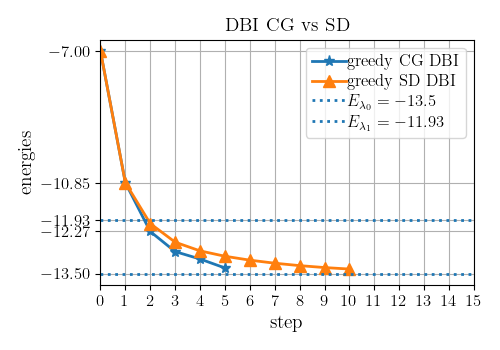

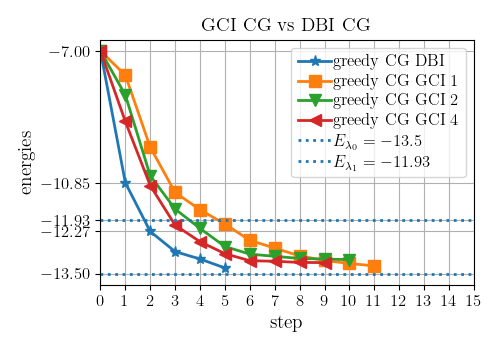

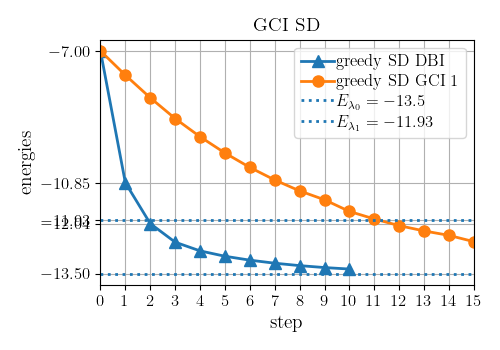

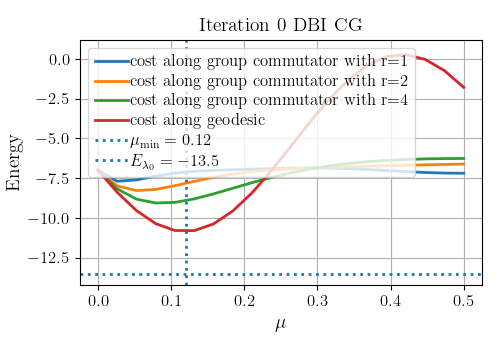

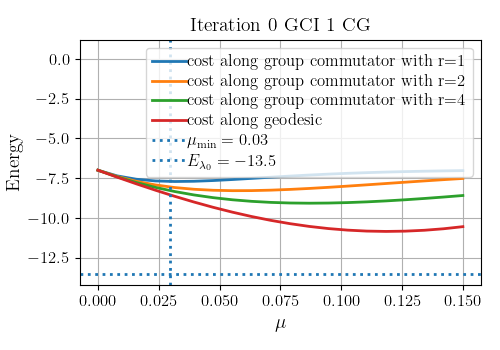

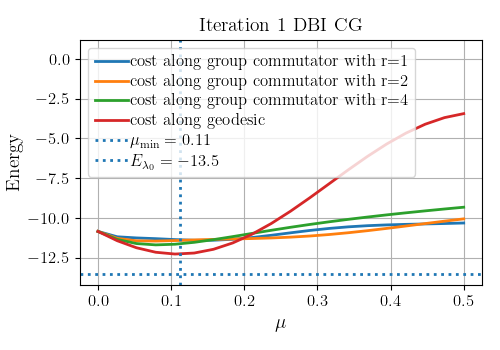

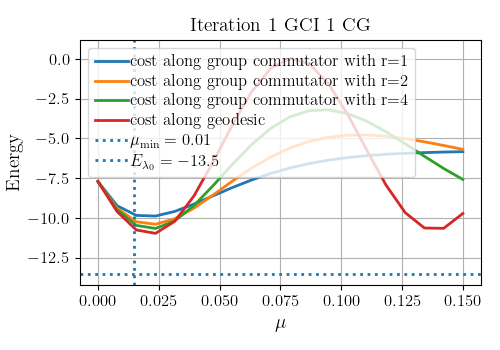

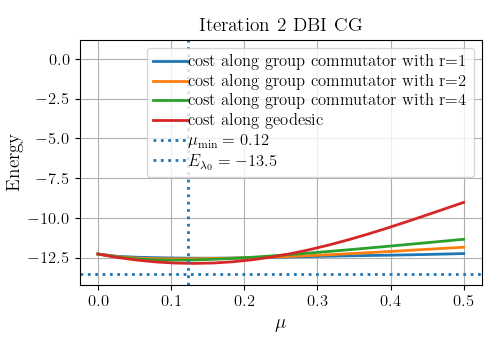

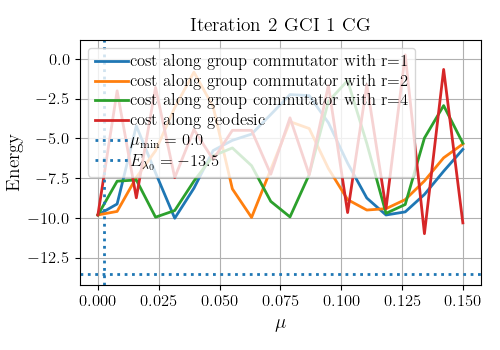

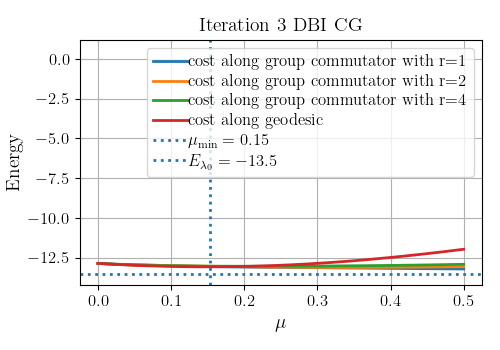

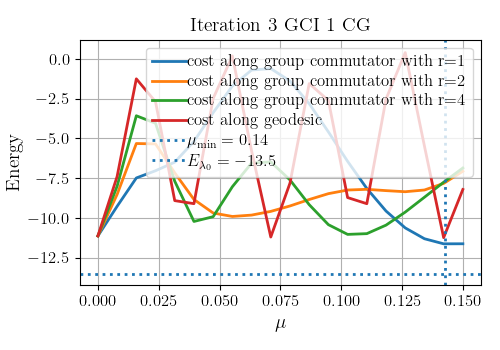

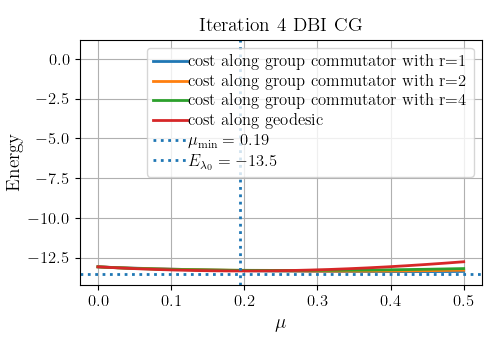

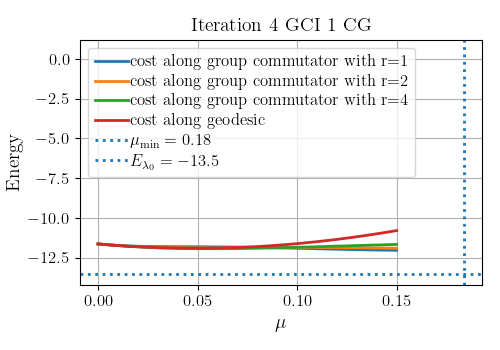

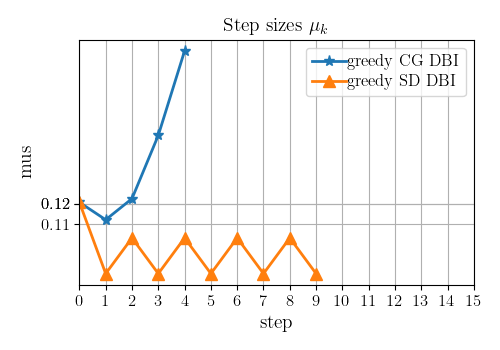

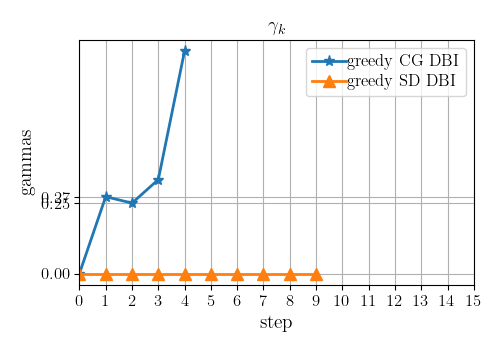

In [336]:
print("target energy is", target_energy)


grid_CG = descent_algorithm("DBI", mu_line_search, mu_gamma_grid_search, "greedy CG DBI", "*")

line_SD = descent_algorithm("DBI", mu_line_search, mu_line_search, "greedy SD DBI", "^")

grid_CG_GCI1 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 1", "s", num=1)

line_SD_GCI1 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 1", "o", num=1)

# line_SD_GCI2 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 2", ">", num=2)

# line_SD_GCI4 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 4", "p", num=4)

grid_CG_GCI2 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 2", "v", num=2)

grid_CG_GCI4 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 4", "<", num=4)



# for i in range(grid_CG["iterations"]):
#     phi = np.zeros([n,n], dtype=complex)
#     c=1
#     for j in range(i-1, -1,-1):
#         c *= grid_CG["gammas"][j]
#         phi +=  c * (grid_CG["unitaries"][j] @ PSI0 @ dagger(grid_CG["unitaries"][j]))
#     phi += grid_CG["unitaries"][i]@PSI0@dagger(grid_CG["unitaries"][i])

#     group_comm_plot(grid_CG["unitaries"][i], grid_CG["velocities"][i], phi, [1,2,4], i)
# poly_SD = general_cg(mu_poly_approx, mu_poly_approx, "$\gamma_k = 0, \mu_k = \mu_\mathrm{poly}$", "p")
# toplot.append(poly_SD)

# auto_pr_CG = general_cg(mu_line_search, mu_gamma_auto_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{poly}$", "s")
# toplot.append(auto_pr_CG)

# line_pr_CG = general_cg(mu_line_search, mu_line_gamma_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{min}$", "o")
# toplot.append(line_pr_CG)

# plot energies
iter_plot([grid_CG, line_SD], "energies", "DBI CG vs SD",hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
                                                  {"mark": excited_energy, "label": f"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_GCI4], "energies", "GCI CG vs DBI CG", hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
                                                  {"mark": excited_energy, "label": f"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

iter_plot([line_SD, line_SD_GCI1], "energies", "GCI SD", hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
                                                  {"mark": excited_energy, "label": f"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])


for x in range(grid_CG["iterations"]):
    group_comm_plot(grid_CG["unitaries"][x], grid_CG["velocities"][x], grid_CG["PHIs"][x], f"Iteration {x} DBI CG", 
                    vlines=[{"mark": grid_CG["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG["mus"][x],2)}$"}],
                    hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

    # group_comm_plot(line_SD["unitaries"][x], line_SD["velocities"][x], line_SD["PHIs"][x], f"Iteration {x} DBI SD", 
    #                 vlines=[{"mark": line_SD["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(line_SD["mus"][x],2)}$"}],
    #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])
    
    group_comm_plot(grid_CG_GCI1["unitaries"][x], grid_CG_GCI1["velocities"][x], grid_CG_GCI1["PHIs"][x], f"Iteration {x} GCI 1 CG", 
                    vlines=[{"mark": grid_CG_GCI1["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI1["mus"][x],2)}$"}],
                    hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}], mu_upper=0.15)

    # group_comm_plot(grid_CG_GCI2["unitaries"][x], grid_CG_GCI2["velocities"][x], grid_CG_GCI2["PHIs"][x], f"Iteration {x} GCI 2 CG", 
    #                 vlines=[{"mark": grid_CG_GCI2["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI2["mus"][x],2)}$"}],
    #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

    # group_comm_plot(grid_CG_GCI4["unitaries"][x], grid_CG_GCI4["velocities"][x], grid_CG_GCI4["PHIs"][x], f"Iteration {x} GCI 4 CG", 
    #                 vlines=[{"mark": grid_CG_GCI4["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI4["mus"][x],2)}$"}],
    #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

iter_plot([grid_CG, line_SD], "mus", "Step sizes $\mu_k$")
iter_plot([grid_CG, line_SD], "gammas", "$\gamma_k$")